In [1]:
## Vloco de codigo para instalar versao especifica dos pacotes
##pip install pandas==1.5.3
##pip install numpy==1.24.3

##### Carregando pacotes

In [5]:
# Pacotes de manipulacao

import pandas as pd
import numpy as np
import os

# Pacotes de visualizacao
import matplotlib.pyplot as plt
import seaborn as sns

print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 1.5.3
numpy: 1.24.3


## Carregando databases

#### Base Telco

In [8]:
## Carregando todos arquivos em parquet de uma pasta

path = 'database/raw/base_telco/base_telco'

all_files = [os.path.join(path, f) for f in os.listdir(path) if f.endswith('.parquet')]
df_list = [pd.read_parquet(f, engine='pyarrow') for f in all_files]

df_base_telco = pd.concat(df_list, ignore_index=True)

In [9]:
df_base_telco.head()

,NUM_CPF,SAFRA,FLAG_INSTALACAO,FPD,PROD,flag_mig2,var_26,var_27,var_28,var_29,...,var_84,var_85,var_86,var_87,var_88,var_89,var_90,var_91,var_92,var_93
0,7779ZY78YXT,202411,1,1,CMV,PRE,1,1,0,80.93,...,304,304,1,3,6,0,1.33,1,2,0
1,777YXTNZWZN,202410,1,0,CMV,PRE,1,1,0,304,...,304,304,3,3,1,0,0.99,5,1,0
2,777ZXUXZZXT,202503,1,0,CMV,PRE,1,1,84.86,99.99,...,304,304,3,1,1,17,1.24,5,1,1
3,777ZXZTUU7Y,202412,1,0,CMV,PRE,1,1,25.5,87.98,...,304,304,304,304,304,304,304,304,304,304
4,7788N7YZN87,202412,1,0,CMV,PRE,1,1,0,70.39,...,1,1,0,1,1,100,1.02,1,1,6


### Funções

Bloco destinado a criação das funcoes que serao utilizados ao longo deste notebook

In [10]:
# Metadados referente ao conjunto de dados
def generate_metadata(dataframe):
    """
    Gera um dataframe contendo metadados das colunas do dataframe fornecido.

    :param dataframe: DataFrame para o qual os metadados serão gerados.
    :return: DataFrame contendo metadados.
    """

    # Coleta de metadados básicos
    metadata = pd.DataFrame({
        'nome_variavel': dataframe.columns,
        'tipo': dataframe.dtypes,
        'qt_nulos': dataframe.isnull().sum(),
        'percent_nulos': round((dataframe.isnull().sum() / len(dataframe))* 100,2),
        'cardinalidade': dataframe.nunique(),
    })
    metadata=metadata.sort_values(by='percent_nulos',ascending=True)
    metadata = metadata.reset_index(drop=True)

    return metadata

In [15]:
def boxplots_var_num(dataframe):
    """
    Plota boxplots para todas as variáveis numéricas do dataframe fornecido em um painel com 3 gráficos por linha.

    :param dataframe: DataFrame para o qual os boxplots serão gerados.
    """
    # Seleciona apenas colunas numéricas
    numeric_columns = dataframe.select_dtypes(include=['float64', 'int64']).columns

    # Define o número de linhas com base no número de colunas numéricas
    nrows = len(numeric_columns) // 3 + (len(numeric_columns) % 3 > 0)

    # Inicializa o painel de gráficos
    fig, axes = plt.subplots(nrows=nrows, ncols=3, figsize=(14, nrows * 4))

    # Ajusta o layout
    plt.tight_layout(pad=4)

    # Configura estilo e paleta de cores
    sns.set_style("whitegrid")

    # Plota boxplots para cada coluna numérica
    for i, column in enumerate(numeric_columns):
        sns.boxplot(data=dataframe[column], ax=axes[i//3, i%3], color="skyblue")
        axes[i//3, i%3].set_title(f'{column}', fontdict={'fontsize': 14, 'fontweight': 'bold'})
        axes[i//3, i%3].set_ylabel('')

    # Remove gráficos vazios (se houver)
    for j in range(i+1, nrows*3):
        fig.delaxes(axes.flatten()[j])

    # Adiciona título principal
    fig.suptitle("Análise descritiva - Boxplots", fontsize=20, fontweight='bold', y=1.00)

In [39]:
def histplots_var_num(dataframe, bins=30):
    """
    Plota histogramas para todas as variáveis numéricas do dataframe fornecido
    em um painel com 3 gráficos por linha.

    :param dataframe: DataFrame para o qual os histogramas serão gerados.
    :param bins: Número de bins do histograma (default = 30).
    """
    # Seleciona apenas colunas numéricas
    numeric_columns = dataframe.select_dtypes(include=['float64', 'int64']).columns

    # Define o número de linhas com base no número de colunas numéricas
    nrows = len(numeric_columns) // 3 + (len(numeric_columns) % 3 > 0)

    # Inicializa o painel de gráficos
    fig, axes = plt.subplots(nrows=nrows, ncols=3, figsize=(14, nrows * 4))

    # Ajusta o layout
    plt.tight_layout(pad=4)

    # Configura estilo
    sns.set_style("whitegrid")

    # Plota histogramas para cada coluna numérica
    for i, column in enumerate(numeric_columns):
        sns.histplot(
            data=dataframe,
            x=column,
            bins=bins,
            kde=True,
            ax=axes[i // 3, i % 3],
            color="skyblue"
        )
        axes[i // 3, i % 3].set_title(
            f'{column}',
            fontdict={'fontsize': 14, 'fontweight': 'bold'}
        )
        axes[i // 3, i % 3].set_ylabel('')

    # Remove gráficos vazios (se houver)
    for j in range(i + 1, nrows * 3):
        fig.delaxes(axes.flatten()[j])

    # Adiciona título principal
    fig.suptitle(
        "Análise descritiva - Histogramas",
        fontsize=20,
        fontweight='bold',
        y=1.00
    )


### Analise dos dados

In [14]:
df_base_telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1367104 entries, 0 to 1367103
Data columns (total 74 columns):
 #   Column           Non-Null Count    Dtype 
---  ------           --------------    ----- 
 0   NUM_CPF          1367104 non-null  object
 1   SAFRA            1367104 non-null  object
 2   FLAG_INSTALACAO  1367104 non-null  object
 3   FPD              1321168 non-null  object
 4   PROD             1367104 non-null  object
 5   flag_mig2        1308974 non-null  object
 6   var_26           1365809 non-null  object
 7   var_27           1365809 non-null  object
 8   var_28           1365809 non-null  object
 9   var_29           1365809 non-null  object
 10  var_30           1365809 non-null  object
 11  var_31           1365809 non-null  object
 12  var_32           1365809 non-null  object
 13  var_33           1365809 non-null  object
 14  var_34           1365809 non-null  object
 15  var_35           1365809 non-null  object
 16  var_36           1365809 non-null  o

In [11]:
generate_metadata(df_base_telco)

,nome_variavel,tipo,qt_nulos,percent_nulos,cardinalidade
0,NUM_CPF,object,0,0.00,1272095
1,var_91,object,0,0.00,15
2,var_90,object,0,0.00,1515
3,var_89,object,0,0.00,107
4,var_88,object,0,0.00,13
...,...,...,...,...,...
69,var_61,object,1295,0.09,4973
70,var_50,object,1295,0.09,6810
71,var_56,object,1295,0.09,91
72,FPD,object,45936,3.36,2


Olhando os metadados de cada coluna, ja podemos observar que:
- Metade das colunas possuem um percentual de nulos superior a 50%
- 25 colunas com o nome apenas como VAR_n
- Todas as colunas estao com o data type object

### Analise univariada

Antes de seguirmos com a estruturação da tabela iremos analisar como os dados estão distribuidos.
Seguiremos com a ordem das colunas com o menor para o maior percentual de nulos.

#### 01 - NUM_CPF

In [13]:
df_base_telco['NUM_CPF'].value_counts().sort_values(ascending=False)

888W78UZYYT    6
ZU7N8UW8XYX    5
YTWN99NY8ZU    5
XYTY9ZX879Z    5
XNXXWZZ97TZ    5
              ..
U77T7N798UY    1
TZZYUT7UUU9    1
U77WNY8WWYZ    1
U77WWX7W88U    1
ZZZZXWZYWZY    1
Name: NUM_CPF, Length: 1272095, dtype: int64

Para o processo de ETL:
- Nome: CPF
- Transformar coluna em VARCHAR
- Possuimos valores 

#### 02 - Safra

In [17]:
df_base_telco['SAFRA'].value_counts().sort_index()

202410    219860
202411    240520
202412    241453
202501    233710
202502    214665
202503    216896
Name: SAFRA, dtype: int64

In [18]:
print('Inicio da safra: ', df_base_telco['SAFRA'].min())
print('Fim da safra: ', df_base_telco['SAFRA'].max())

Inicio da safra:  202410
Fim da safra:  202503


Para o processo de ETL:
- Nome: Safra
- Transformar coluna em INT
- Criar duas nova colunas: Ano e Mes

#### 02 - FLAG_INSTALACAO

In [19]:
df_base_telco['FLAG_INSTALACAO'].value_counts()

1    1321168
0      45936
Name: FLAG_INSTALACAO, dtype: int64

In [22]:
# Iremos transformar essa coluna em tipo numerico
df_base_telco['FLAG_INSTALACAO'] = df_base_telco['FLAG_INSTALACAO'].astype('int')

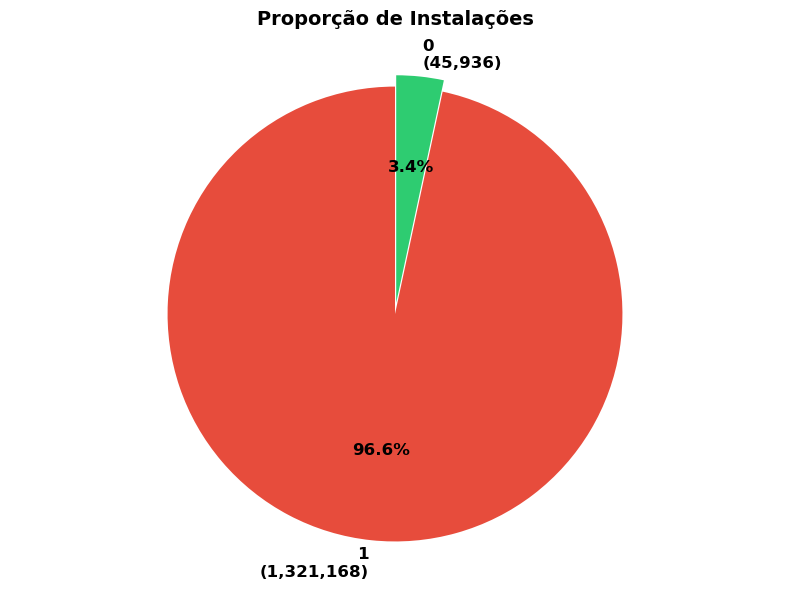

In [23]:
dados = df_base_dados_cadastrais['FLAG_INSTALACAO'].value_counts()

plt.figure(figsize=(8, 6))
colors = ['#e74c3c', '#2ecc71']  # vermelho e verde
explode = (0.05, 0)  # destaca a primeira fatia

plt.pie(
    dados.values,
    labels=[f'{label}\n({value:,})' for label, value in zip(dados.index, dados.values)],
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=90,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

plt.title('Proporção de Instalações', fontsize=14, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

Para o processo ETL:
- Nome: IsSetup ou IsInstallation
- TIpo de dado: boolean
- Criar variável descritiva

#### 03 - FPD

In [24]:
df_base_telco['FPD'].value_counts()

0    1006838
1     314330
Name: FPD, dtype: int64

In [28]:
# Iremos filtrar os valores nulos da coluna FPD
df_base_telco[df_base_telco['FPD'].isnull()]

,NUM_CPF,SAFRA,FLAG_INSTALACAO,FPD,PROD,flag_mig2,var_26,var_27,var_28,var_29,...,var_84,var_85,var_86,var_87,var_88,var_89,var_90,var_91,var_92,var_93
36,77Y89T9TWZZ,202411,0,None,CMV,None,1,1,0,82.98,...,304,304,304,304,304,304,304,304,304,304
84,78NZ9X9UWTW,202411,0,None,CMV,None,303,303,303,303,...,303,303,303,303,303,303,303,303,303,303
93,78UYZ8YY9U9,202410,0,None,CMV,None,1,1,83.14,24.49,...,5,1,304,304,304,304,304,304,304,304
125,799ZY8ZUYN8,202501,0,None,CMV,None,0,0,304,304,...,304,4,304,304,304,304,304,304,304,304
138,79T9XUZZNT9,202410,0,None,NET,None,303,303,303,303,...,303,303,303,303,303,303,303,303,303,303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1366924,ZZWUN7XXY9Z,202410,0,None,CMV,None,1,1,304,304,...,304,304,304,304,304,304,304,304,304,304
1366978,ZZXN77Z8XXY,202411,0,None,CMV,None,1,1,86.57,99.51,...,304,304,304,304,1,304,304,304,1,304
1366985,ZZXTW898YZ8,202412,0,None,NET,None,1,0,304,304,...,304,304,304,304,304,304,304,304,304,304
1367055,ZZYXUNTZTW7,202501,0,None,CMV,None,1,1,0,304,...,304,304,304,304,304,304,304,304,304,304


Todos os valores nulos da coluna FPD coincidem com valores nulos também na colima flag_mig_2. Estas informações podem representar o mesmo dado ou terem valores atrelados entre si.

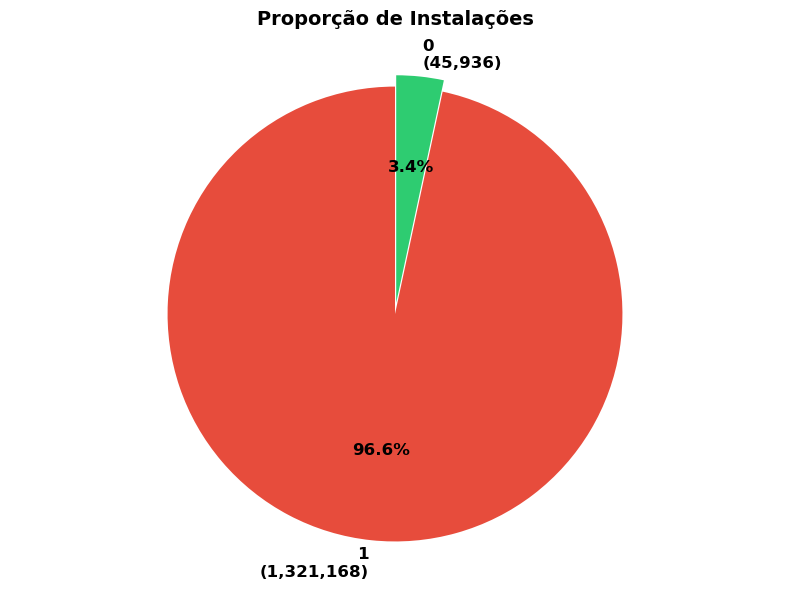

In [29]:
dados = df_base_telco['FLAG_INSTALACAO'].value_counts()

plt.figure(figsize=(8, 6))
colors = ['#e74c3c', '#2ecc71']  # vermelho e verde
explode = (0.05, 0)  # destaca a primeira fatia

plt.pie(
    dados.values,
    labels=[f'{label}\n({value:,})' for label, value in zip(dados.index, dados.values)],
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=90,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

plt.title('Proporção de Instalações', fontsize=14, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

Para o processo ETL:
- Nome: IsFPD
- TIpo de dado: boolean
- Entender como iremos tratar os valores nulos: existiu a instalação ou não? Descartaremos?

#### 04 - PROD

In [30]:
df_base_telco['PROD'].value_counts()

CMV    1346917
NET      16209
DTH       3978
Name: PROD, dtype: int64

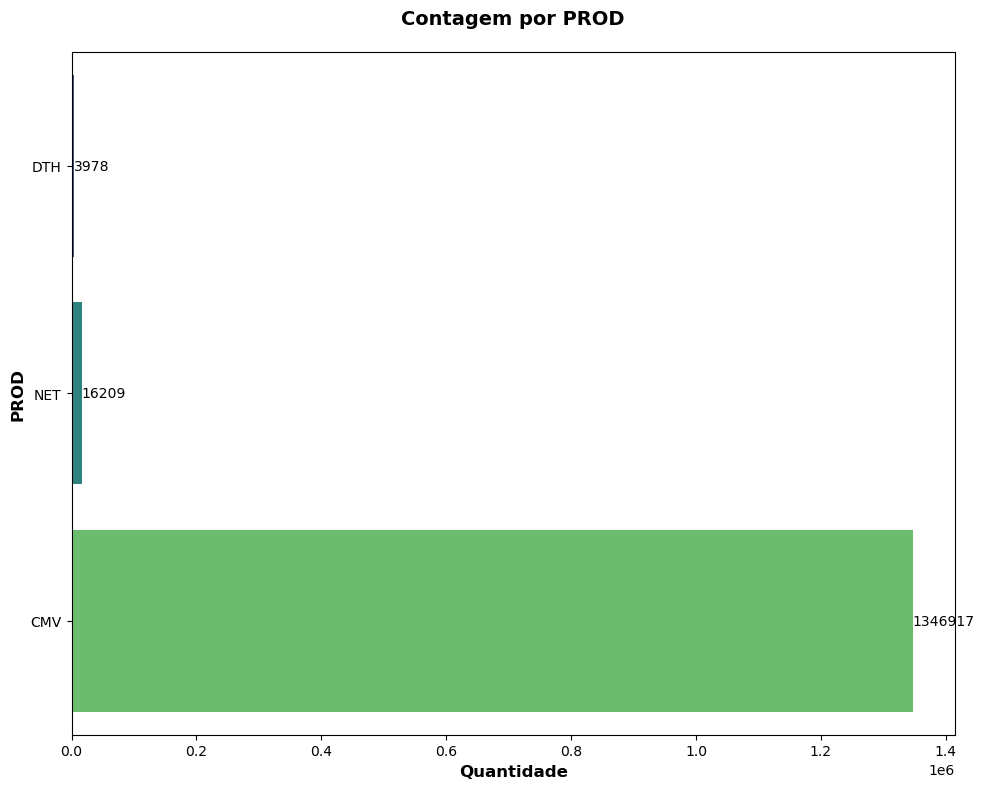

In [31]:
# Preparar dados agregados
dados_agregados = df_base_telco.groupby('PROD').size().reset_index(name='count')
dados_agregados = dados_agregados.sort_values('count', ascending=True)  # ordena para melhor visualização

plt.figure(figsize=(10, 8))
sns.barplot(
    data=dados_agregados,
    y='PROD',
    x='count',
    palette='viridis',
    orient='h'
)

plt.title('Contagem por PROD', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Quantidade', fontsize=12, fontweight='bold')
plt.ylabel('PROD', fontsize=12, fontweight='bold')

# Adicionar valores nas barras
for i, v in enumerate(dados_agregados['count']):
    plt.text(v + 0.5, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

Para o processo de ETL:

- Nome: ProductDescription
- Tipo de dado: Varchar

#### 05 - flag_mig2

In [33]:
df_base_telco['flag_mig2'].value_counts()

PRE          1290526
Aquisição      18362
FLEX              86
Name: flag_mig2, dtype: int64

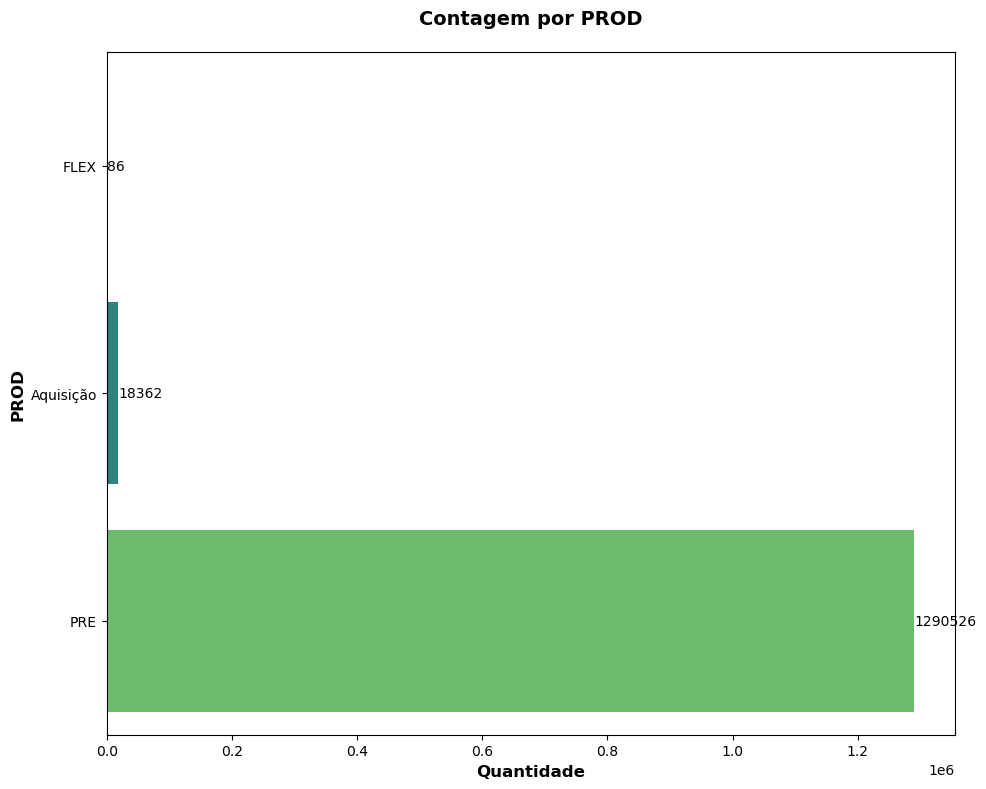

In [35]:
# Preparar dados agregados
dados_agregados = df_base_telco.groupby('flag_mig2').size().reset_index(name='count')
dados_agregados = dados_agregados.sort_values('count', ascending=True)  # ordena para melhor visualização

plt.figure(figsize=(10, 8))
sns.barplot(
    data=dados_agregados,
    y='flag_mig2',
    x='count',
    palette='viridis',
    orient='h'
)

plt.title('Contagem por PROD', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Quantidade', fontsize=12, fontweight='bold')
plt.ylabel('PROD', fontsize=12, fontweight='bold')

# Adicionar valores nas barras
for i, v in enumerate(dados_agregados['count']):
    plt.text(v + 0.5, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

Esta variavel contem os dados de CPFs que migraram de dados, sera necessario entender se este dado era o tipo de produto que ele contratou anteriormente ou se é o plano que ele entrou

Para o processo de ETL:

- Nome: ProductMigration
- Tipo de dado: Varchar

#### 06 - Analise das variaveis var_xx

Nesta secao iremos olhar a distribuicao destas variaveis. Todas sao numericas e nao temos como inferir o que cada uma significa

In [36]:
## Transformando todos as colunas que começam com var_ sem numerico
for col in df_base_telco.columns:
    if col.startswith('var_'):
        df_base_telco[col] = pd.to_numeric(df_base_telco[col], errors='coerce')

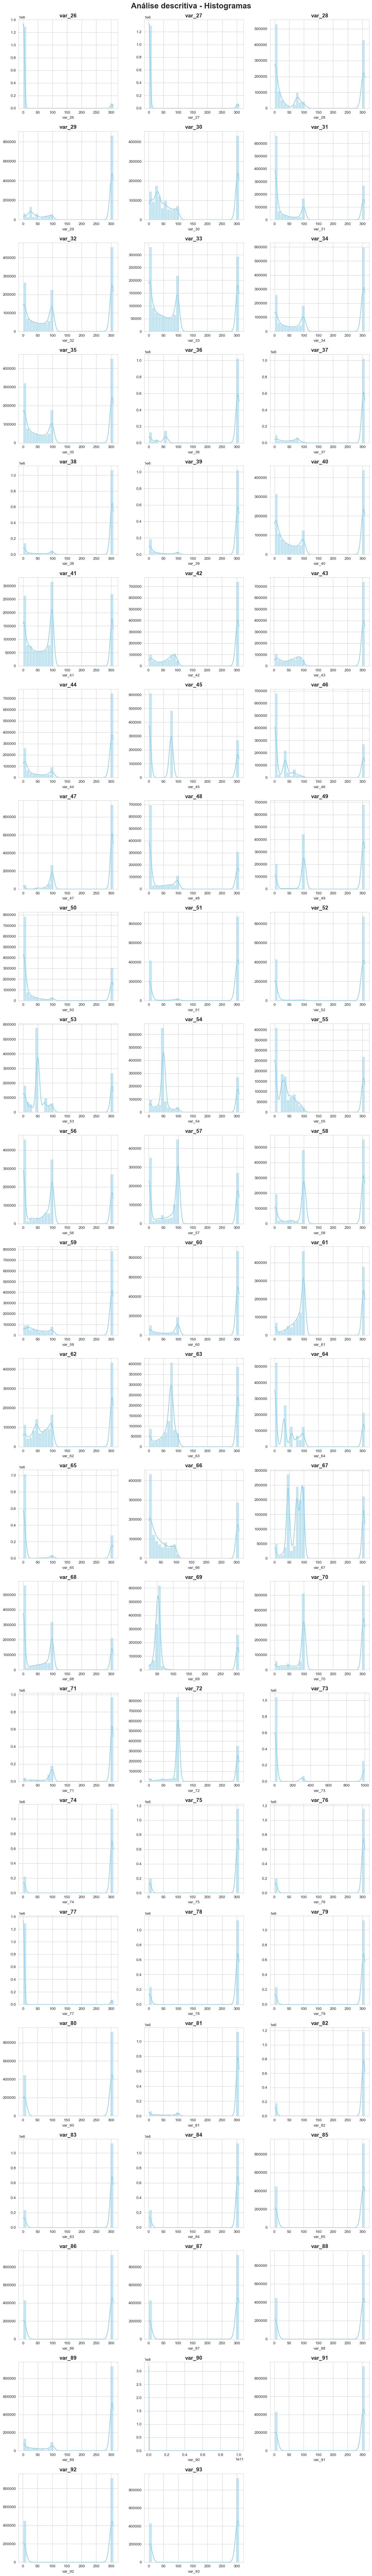

In [41]:
## Agora aplicaremos a funcao de boxplot nas variaveis numericas
histplots_var_num(df_base_telco)

### Analise da PLK: NUM_CPF

Como conseguimos averiguar anteriormente, a coluna com o identificador único CPF possui dados duplicamos. 

Iremos analisar o padrão dessa repetição para podermos seguir com a criação da camada silver.

In [42]:
## Separando o dataset onde a coluna NUM_CPF possua duplicidade
df_base_telco_duplicados = df_base_telco[df_base_telco.duplicated(subset=['NUM_CPF'], keep=False)]

In [ ]:
# Vamos criar uma coluna auxiliar para contar a quantidade de repetições de cada CPF e ordenar o dataframe
df_base_telco_duplicados['qtd_repeticoes'] = (
    df_base_telco_duplicados
        .groupby('NUM_CPF')['NUM_CPF']
        .transform('count')
)

df_base_telco_duplicados \
    .sort_values('qtd_repeticoes', ascending=False)


,NUM_CPF,SAFRA,FLAG_INSTALACAO,FPD,PROD,flag_mig2,var_26,var_27,var_28,var_29,...,var_85,var_86,var_87,var_88,var_89,var_90,var_91,var_92,var_93,qtd_repeticoes
561594,888W78UZYYT,202412,0,None,CMV,None,1.0,1.0,304.0,304.0,...,2,4,3,1,33,298.00,5,1,1,6
561595,888W78UZYYT,202501,1,1,CMV,PRE,1.0,1.0,304.0,304.0,...,2,4,3,1,33,1.27,5,1,1,6
561593,888W78UZYYT,202411,1,1,CMV,PRE,1.0,1.0,304.0,304.0,...,2,3,3,1,50,298.00,3,1,1,6
561592,888W78UZYYT,202410,1,1,CMV,PRE,1.0,1.0,304.0,304.0,...,2,304,304,304,304,304.00,304,304,304,6
561597,888W78UZYYT,202503,0,None,CMV,None,1.0,1.0,304.0,304.0,...,2,4,3,1,29,0.87,6,3,1,6


In [52]:
df_base_telco_duplicados

,NUM_CPF,SAFRA,FLAG_INSTALACAO,FPD,PROD,flag_mig2,var_26,var_27,var_28,var_29,...,var_85,var_86,var_87,var_88,var_89,var_90,var_91,var_92,var_93,qtd_repeticoes
27,77UU8TW79YZ,202502,1,0,CMV,PRE,0.0,0.0,304.0,304.00,...,304,304,304,304,304,304.00,304,304,304,2
28,77UU8TW79YZ,202503,1,1,DTH,None,0.0,0.0,304.0,304.00,...,304,304,304,304,304,304.00,304,304,304,2
36,77Y89T9TWZZ,202411,0,None,CMV,None,1.0,1.0,0.0,82.98,...,304,304,304,304,304,304.00,304,304,304,2
37,77Y89T9TWZZ,202502,1,0,CMV,PRE,1.0,1.0,0.0,304.00,...,304,304,304,304,304,304.00,304,304,304,2
38,77Y89YN9YN8,202411,1,0,CMV,PRE,1.0,1.0,304.0,304.00,...,304,304,304,6,304,304.00,304,1,304,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1367035,ZZYNZ88Y7U7,202412,1,0,CMV,PRE,1.0,1.0,100.0,99.99,...,304,304,304,304,304,304.00,304,304,304,2
1367055,ZZYXUNTZTW7,202501,0,None,CMV,None,1.0,1.0,0.0,304.00,...,304,304,304,304,304,304.00,304,304,304,2
1367056,ZZYXUNTZTW7,202502,1,1,CMV,PRE,1.0,1.0,0.0,304.00,...,304,304,304,304,304,304.00,304,304,304,2
1367084,ZZZTNN7YN7T,202412,0,None,CMV,None,1.0,1.0,0.0,82.98,...,4,3,4,1,7,1.13,6,1,0,2


In [45]:
df_base_telco_duplicados.shape

(182689, 74)

In [46]:
## Vamos realizar o drop onde toda a linha esteja duplicada
df_base_telco_duplicados = df_base_telco_duplicados.drop_duplicates()

In [53]:
df_base_telco_duplicados.shape

(182689, 75)

In [54]:
## Vamos analisar qual a porcentagem de duplicados no dataset original
porcentagem_duplicados = (df_base_telco_duplicados['NUM_CPF'].nunique() / df_base_telco['NUM_CPF'].nunique()) * 100
porcentagem_duplicados

6.892566985956237